# mRmR Feature Selection — Example Notebook

Demonstrates **P0 `mRmRSelector`** on the SCANB gene-expression dataset with **two tasks**,
both using the **already-computed** `data/correlation_matrix.csv` (9 266 features + `is_lumA` + `Lympho`).

| Task | Target column | Type |
|------|--------------|------|
| **Classification** | `is_lumA` (binary: LumA vs rest) | `classification` |
| **Regression** | `Lympho` (continuous lymphocyte score) | `regression` |

Because both target columns already exist in the matrix, **no lazy hot-cache** is
needed for target relevance — every score is pre-loaded from disk.

The classification task is also compared against the **LR random baseline**.

## 0 — Imports & paths

In [1]:
import sys, os
# Make sure the package root is on the path when running from feature_selection/src/
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from feature_selection.src.preprocessing import train_test_val_split
from feature_selection.src.filter.mRmR import mRmRSelector, SelectionResult
from feature_selection.src.LR_random_baseline import train_and_evaluate_logistic_regression

# ── Paths (relative to notebook location: feature_selection/src/) ──────────
DATA_PATH  = '../data/SCANB.csv'
LABEL_PATH = '../data/sampleinfo_SCANB_t.csv'
CORR_PATH  = '../data/correlation_matrix.csv'  # 9 266 features + is_lumA + Lympho

RANDOM_SEED = 2
N_FEATURES  = 20

## 1 — Load data & build train / validation splits

In [2]:
gene_expression_df = pd.read_csv(DATA_PATH)
sampleinfo_df      = pd.read_csv(LABEL_PATH)

# Binary LumA label
sampleinfo_df['is_lumA'] = (sampleinfo_df['PAM50'] == 'LumA').astype(int)

# 70 % train / 10 % val / 20 % test
train_si, val_si, _ = train_test_val_split(
    sampleinfo_df, random_seed=RANDOM_SEED, train_pcnt=0.7, val_pct=0.1
)
train_labels_df = train_si[['samplename', 'is_lumA']].reset_index(drop=True)
val_labels_df   = val_si[['samplename', 'is_lumA']].reset_index(drop=True)

print(f'Train samples : {len(train_labels_df)}')
print(f'Val   samples : {len(val_labels_df)}')
print(f"LumA prevalence (train): {train_labels_df['is_lumA'].mean():.2%}")

# Transpose gene-expression (genes × samples) → (samples × genes)
ge_proc = gene_expression_df.copy().fillna(0).set_index('Unnamed: 0').T
ge_proc.index.name = 'samplename'
X_train = ge_proc.loc[train_labels_df['samplename']]
print(f'\nX_train shape : {X_train.shape}')

Train samples : 2148
Val   samples : 306
LumA prevalence (train): 49.30%

X_train shape : (2148, 9264)


## 2 — Build target series

Both targets are already stored in `correlation_matrix.csv` under their real column names.
We just need correctly-named `pd.Series` objects so that `mRmRSelector` can locate them.

In [3]:
# Classification target: is_lumA  (name must match the column in the matrix)
y_lumA = (
    train_labels_df.set_index('samplename')['is_lumA']
    .reindex(X_train.index)
)  # Series.name == 'is_lumA'  ✓

# Regression target: Lympho  (name must match the column in the matrix)
y_lympho = (
    sampleinfo_df.set_index('samplename')['Lympho']
    .reindex(X_train.index)
)  # Series.name == 'Lympho'  ✓

print(f'y_lumA  name={y_lumA.name!r}   dtype={y_lumA.dtype}   nunique={y_lumA.nunique()}')
print(f'y_lympho name={y_lympho.name!r}  dtype={y_lympho.dtype}   nunique={y_lympho.nunique()}')

y_lumA  name='is_lumA'   dtype=int64   nunique=2
y_lympho name='Lympho'  dtype=float64   nunique=2148


---
## Task A — Classification: predict `is_lumA`

### A.1 — Run mRmR selector

`correlation_filepath=CORR_PATH` loads the pre-computed matrix.  
The `is_lumA` column is present → no lazy hot-cache for target relevance.

In [4]:
selector_clf = mRmRSelector(
    X_train=X_train,
    y_train=y_lumA,                   # name='is_lumA' → looked up in the matrix
    relevance_method='pearson',
    mrmr_score_method='difference',
    correlation_filepath=CORR_PATH,
    # ── per-step LR evaluation ─────────────────────────────────────────
    gene_expression_df=gene_expression_df,
    train_labels_df=train_labels_df,
    val_labels_df=val_labels_df,
    random_seed=RANDOM_SEED,
)

result_clf: SelectionResult = selector_clf.forward_selection(
    n_features_to_select=N_FEATURES
)
print()
print(result_clf)

2026-04-03 21:59:26,107 [INFO] mRmRSelector: mRmRSelector initialised | task_type=classification | target_col=is_lumA | relevance_method=pearson | mrmr_score_method=difference
Correlation matrix loaded from ../data/correlation_matrix.csv
2026-04-03 21:59:50,826 [INFO] mRmRSelector: Loaded correlation matrix from ../data/correlation_matrix.csv (9266, 9266)
2026-04-03 21:59:50,832 [INFO] mRmRSelector: Starting forward selection for up to 20 features
2026-04-03 21:59:50,925 [INFO] mRmRSelector: Step 1: selected 'MYBL2' (1 total)
2026-04-03 21:59:51,443 [INFO] mRmRSelector: Step 1 eval — accuracy: 0.7778  macro F1: 0.7776
2026-04-03 21:59:55,581 [INFO] mRmRSelector: Step 2: selected 'ATP13A2' (2 total)
2026-04-03 21:59:56,286 [INFO] mRmRSelector: Step 2 eval — accuracy: 0.8007  macro F1: 0.8007
2026-04-03 22:00:00,300 [INFO] mRmRSelector: Step 3: selected 'SLC24A2' (3 total)
2026-04-03 22:00:01,037 [INFO] mRmRSelector: Step 3 eval — accuracy: 0.8333  macro F1: 0.8330
2026-04-03 22:00:05,70

### A.2 — Selected features

In [5]:
print('Classification — selected features (in order):')
for i, f in enumerate(result_clf.selected_features, 1):
    print(f'  {i:2d}. {f}')

Classification — selected features (in order):
   1. MYBL2
   2. ATP13A2
   3. SLC24A2
   4. SHCBP1
   5. PGR
   6. BIRC5
   7. TMPRSS3
   8. MAPT
   9. TUBA1B
  10. MATN3
  11. CALML3
  12. CDC45
  13. EVL
  14. PTTG1
  15. FLNB
  16. FAM189A1
  17. POLQ
  18. NAT1
  19. TROAP
  20. MTHFR


In [9]:
result_clf.performance_history[0]

{'0': {'precision': 0.7454545454545455,
  'recall': 0.825503355704698,
  'f1-score': 0.7834394904458599,
  'support': 149.0},
 '1': {'precision': 0.8156028368794326,
  'recall': 0.732484076433121,
  'f1-score': 0.7718120805369127,
  'support': 157.0},
 'accuracy': 0.7777777777777778,
 'macro avg': {'precision': 0.7805286911669891,
  'recall': 0.7789937160689095,
  'f1-score': 0.7776257854913864,
  'support': 306.0},
 'weighted avg': {'precision': 0.7814456622967261,
  'recall': 0.7777777777777778,
  'f1-score': 0.7774737932049949,
  'support': 306.0}}

### A.3 — LR random baseline at matching feature-count checkpoints

In [12]:
N_RUNS      = 10
checkpoints = list(range(1, N_FEATURES + 1))

baseline_records = []
for run_id in range(N_RUNS):
    for n in checkpoints:
        _, rep = train_and_evaluate_logistic_regression(
            gene_expression_df=gene_expression_df,
            train_labels_df=train_labels_df,
            val_labels_df=val_labels_df,
            n_features=n,
            random_seed=RANDOM_SEED + run_id,
            output_dict=True,
        )
        baseline_records.append({
            'n_features': n, 'run_id': run_id,
            'accuracy': rep.get('accuracy', float('nan')),
            'macro_f1': rep.get('macro avg', {}).get('f1-score', float('nan')),
        })

baseline_df = pd.DataFrame(baseline_records)
baseline_summary = (
    baseline_df.groupby('n_features')[['accuracy', 'macro_f1']]
    .agg(['mean', 'std']).reset_index()
)
baseline_summary.columns = ['n_features', 'acc_mean', 'acc_std', 'f1_mean', 'f1_std']
print(f'Random baseline computed ({N_RUNS} runs × {N_FEATURES} checkpoints).')
display(baseline_summary.head())

/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/netnet/feature_selection/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

Random baseline computed (10 runs × 20 checkpoints).


,n_features,acc_mean,acc_std,f1_mean,f1_std
0,1,0.542157,0.050614,0.511148,0.095235
1,2,0.605229,0.034715,0.604881,0.034663
2,3,0.628431,0.044491,0.627769,0.043979
3,4,0.645752,0.050538,0.645082,0.050261
4,5,0.674510,0.044012,0.673824,0.043893


### A.4 — Comparison plot: mRmR vs LR random baseline

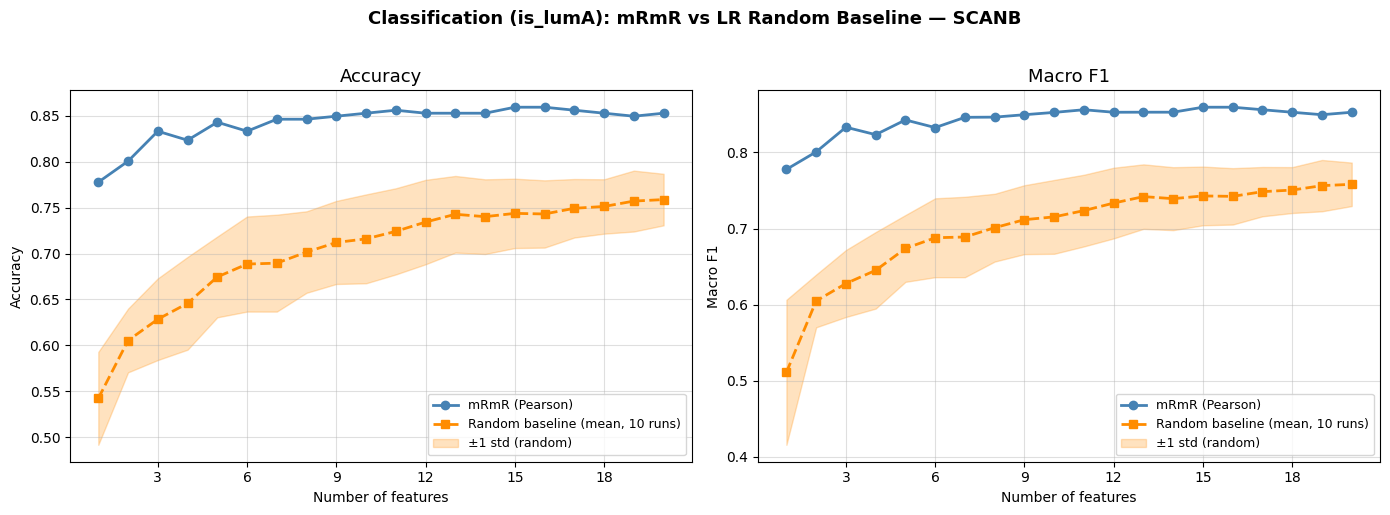

In [13]:
mrmr_clf_records = [
    {
        'n_features': i + 1,
        'accuracy':   rep.get('accuracy', float('nan')),
        'macro_f1':   rep.get('macro avg', {}).get('f1-score', float('nan')),
    }
    for i, rep in enumerate(result_clf.performance_history)
]
mrmr_clf_df = pd.DataFrame(mrmr_clf_records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics = [
    ('accuracy', 'acc_mean', 'acc_std', 'Accuracy'),
    ('macro_f1', 'f1_mean',  'f1_std',  'Macro F1'),
]
for ax, (mrmr_col, bl_mean, bl_std, title) in zip(axes, metrics):
    ax.plot(
        mrmr_clf_df['n_features'], mrmr_clf_df[mrmr_col],
        marker='o', linewidth=2, color='steelblue', label='mRmR (Pearson)'
    )
    bx = baseline_summary['n_features']
    ax.plot(
        bx, baseline_summary[bl_mean],
        marker='s', linewidth=2, color='darkorange',
        linestyle='--', label=f'Random baseline (mean, {N_RUNS} runs)'
    )
    ax.fill_between(
        bx,
        baseline_summary[bl_mean] - baseline_summary[bl_std],
        baseline_summary[bl_mean] + baseline_summary[bl_std],
        alpha=0.25, color='darkorange', label='±1 std (random)'
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Number of features')
    ax.set_ylabel(title)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)

fig.suptitle(
    'Classification (is_lumA): mRmR vs LR Random Baseline — SCANB',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Task B — Regression: predict `Lympho`

> LR evaluation is not applicable for the continuous target.  
> We run mRmR selection only (no per-step evaluation) and inspect the feature ranking.

`correlation_filepath=CORR_PATH` — the same matrix is reused.  
The `Lympho` column is present → no lazy hot-cache.

### B.1 — Run mRmR selector

In [14]:
selector_reg = mRmRSelector(
    X_train=X_train,
    y_train=y_lympho,                 # name='Lympho' → looked up in the matrix
    relevance_method='pearson',
    mrmr_score_method='difference',
    correlation_filepath=CORR_PATH,
    random_seed=RANDOM_SEED,
)

result_reg: SelectionResult = selector_reg.forward_selection(
    n_features_to_select=N_FEATURES
)
print()
print(result_reg)

2026-04-03 22:09:05,098 [INFO] mRmRSelector: mRmRSelector initialised | task_type=regression | target_col=Lympho | relevance_method=pearson | mrmr_score_method=difference
Correlation matrix loaded from ../data/correlation_matrix.csv
2026-04-03 22:09:26,835 [INFO] mRmRSelector: Loaded correlation matrix from ../data/correlation_matrix.csv (9266, 9266)
2026-04-03 22:09:26,841 [INFO] mRmRSelector: Starting forward selection for up to 20 features
2026-04-03 22:09:26,939 [INFO] mRmRSelector: Step 1: selected 'LCK' (1 total)
2026-04-03 22:09:30,830 [INFO] mRmRSelector: Step 2: selected 'NLRP3' (2 total)
2026-04-03 22:09:34,627 [INFO] mRmRSelector: Step 3: selected 'CD19' (3 total)
2026-04-03 22:09:38,472 [INFO] mRmRSelector: Step 4: selected 'FASLG' (4 total)
2026-04-03 22:09:43,472 [INFO] mRmRSelector: Step 5: selected 'IL2RG' (5 total)
2026-04-03 22:09:47,446 [INFO] mRmRSelector: Step 6: selected 'CCR7' (6 total)
2026-04-03 22:09:52,025 [INFO] mRmRSelector: Step 7: selected 'SLAMF7' (7 tot

### B.2 — Selected features & relevance bar chart

Regression — selected features (in order):
   1. LCK
   2. NLRP3
   3. CD19
   4. FASLG
   5. IL2RG
   6. CCR7
   7. SLAMF7
   8. ACAP1
   9. ITK
  10. PRKCB
  11. TRAF3IP3
  12. CD27
  13. PRF1
  14. MAP4K1
  15. BIRC3
  16. SH2D1A
  17. ARHGAP25
  18. CD3G
  19. CD79B
  20. CD48


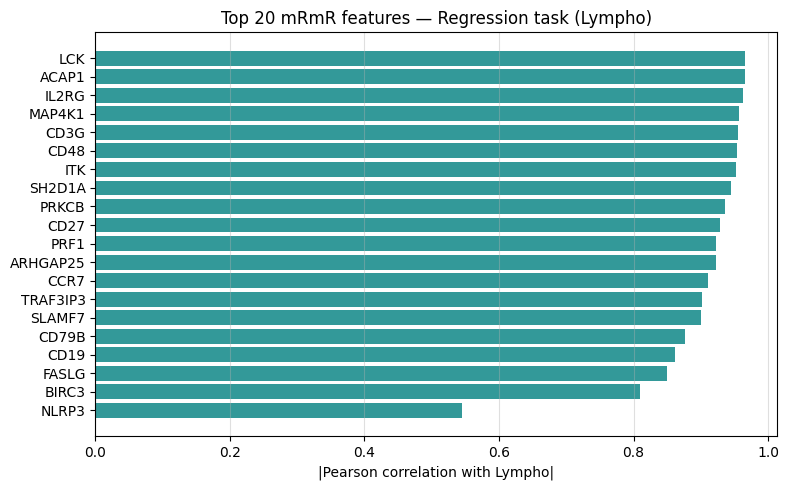

,feature,|Pearson| with Lympho
0,LCK,0.965507
1,ACAP1,0.964966
2,IL2RG,0.962243
3,MAP4K1,0.957126
4,CD3G,0.955461
5,CD48,0.954148
6,ITK,0.952593
7,SH2D1A,0.944318
8,PRKCB,0.935525
9,CD27,0.928347


In [15]:
print('Regression — selected features (in order):')
for i, f in enumerate(result_reg.selected_features, 1):
    print(f'  {i:2d}. {f}')

# Retrieve |Pearson with Lympho| from the populated score matrix
target_col = selector_reg._target_col   # == 'Lympho'
rel_scores = {
    f: selector_reg._score_matrix.loc[f, target_col]
    for f in result_reg.selected_features
}
rel_df = (
    pd.Series(rel_scores, name='|Pearson| with Lympho')
    .reset_index().rename(columns={'index': 'feature'})
    .sort_values('|Pearson| with Lympho', ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(rel_df['feature'][::-1], rel_df['|Pearson| with Lympho'][::-1],
        color='teal', alpha=0.8)
ax.set_xlabel('|Pearson correlation with Lympho|')
ax.set_title(f'Top {N_FEATURES} mRmR features — Regression task (Lympho)', fontsize=12)
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()
display(rel_df)

---
## 3 — Timing summary

In [16]:
print('=== Classification task (is_lumA) ===')
print(f'  Selection time  : {result_clf.selection_time_seconds:.3f}s')
if result_clf.evaluation_time_seconds is not None:
    print(f'  Evaluation time : {result_clf.evaluation_time_seconds:.3f}s  '
          f'({result_clf.n_steps} LR fits)')
print(f'  Stopping reason : {result_clf.stopping_reason}')

print()
print('=== Regression task (Lympho) ===')
print(f'  Selection time  : {result_reg.selection_time_seconds:.3f}s')
print(f'  Stopping reason : {result_reg.stopping_reason}')

=== Classification task (is_lumA) ===
  Selection time  : 100.737s
  Evaluation time : 14.428s  (20 LR fits)
  Stopping reason : max_features_reached

=== Regression task (Lympho) ===
  Selection time  : 97.353s
  Stopping reason : max_features_reached
